# **Pilot Identification: Feature Extraction Approach**

Code written by Micah Yarbrough for the 2025-2026 LeTourneau University FENNEC Senior Design Team.
The objective of the research is to determine if a nerual network is a viable method for identifying a UAV rotorcraft pilot


In [ ]:
import os
import torch
from torch import nn
import numpy as np
import fennec_ml as fn
import pandas as pd
import pilot_tools as pt
import matplotlib.pyplot as plt

# File/Folder Setup
'''
myproject/
├── DATA/
│   ├── TRAIN_FLIGHTS/
│   │   ├── flight111_PA_AA_L.xlxs
│   │   ├── ...
│   │   └── TRAIN_CSV/
│   │       └── ... (can be empty)
│   ├── TEST_FLIGHTS/
│   │   ├── flight222_PB_AA_L.xlxs
│   │   ├── ...
│   │   └── TEST_CSV/
│   │       └── ... (can be empty)
│   ├── PILOTS_BACKUP/
│   │   ├── PILOT_A/
│   │   │   ├── flight111_PA_AA_L.xlxs
│   │   │   └── ...
│   │   ├── PILOT_B/
│   │   │   ├── flight222_PB_AA_L.xlxs
│   │   │   └── ...
│   │   └── ...
│   └── proccessed_data/
│       ├── flight123_AA_L.csv
│       └── ...
├── saved_models/
│   └── ... (can be empty)
├── vars_of_interest.json
├── Annotated Feature Extraction.ipynb
└── PilotModel1.pkl
'''

MAIN_DIR = os.getcwd()
DATA_DIR = os.path.join(MAIN_DIR, "DATA")
TRAIN_DATA_DIR = os.path.join(DATA_DIR, "TRAIN_FLIGHTS")
TRAIN_CSV_DIR = os.path.join(TRAIN_DATA_DIR, "TRAIN_CSV")
TEST_DATA_DIR = os.path.join(DATA_DIR, "TEST_FLIGHTS")
TEST_CSV_DIR = os.path.join(TEST_DATA_DIR, "TEST_CSV")
MODELS_DIR = os.path.join(MAIN_DIR, "SAVED_MODELS")
BACKUP_DIR = os.path.join(DATA_DIR, "PILOTS_BACKUP")

PILOTS = sorted(["LF", "JH","JA"])

## 1. DATA PROCESSING
---

### 1.a Edit and Save Datasets

- Datasets can be made and saved by manually moving the .xlsx files between the folders 
- Use the next cell to print out the code to save the current config and copy and paste it into the following cell to save as a repository for datasets

In [2]:
def print_current_dataset(name='unnamed_dataset'):
        current_train = []
        for file in os.listdir(TRAIN_DATA_DIR):
                filename = os.path.basename(file)
                if filename.lower().endswith(".xlsx"):
                        current_train.append(filename[4:11])
        current_test = []
        for file in os.listdir(TEST_DATA_DIR):
                filename = os.path.basename(file)
                if filename.lower().endswith(".xlsx"): 
                        current_test.append(filename[4:11])

        def format_items(items):
                lines = []
                for i in range(0, len(items), 5):
                        chunk = items[i:i+5]
                        lines.append(', '.join(f"'{item}'" for item in chunk) + ',')
                lines[-1] = lines[-1].rstrip(',')  # remove trailing comma on last line
                return '\n'.join(lines)

        print(f"Copy the below output and paste it into the dataset cell\n{'v'*23}- BELOW -{'v'*23}\n")
        print(f"{name} = {{\n'training':\n[{format_items(current_train)}],\n")
        print(f"'testing':\n[{format_items(current_test)}]\n}}")

new_dataset_name = "JALFJHH"
print_current_dataset(new_dataset_name)

Copy the below output and paste it into the dataset cell
vvvvvvvvvvvvvvvvvvvvvvv- BELOW -vvvvvvvvvvvvvvvvvvvvvvv

JALFJHH = {
'training':
['095G_JA', '097G_JA', '101G_JA', '119G_LF', '120G_LF',
'121G_LF', '128G_LF', '129G_LF', '141G_LF', '142G_LF',
'147B_JA', '152B_JH', '154B_JA', '155G_LF', '156B_JA',
'161B_JA', '167B_JA', '168B_JA', '169B_JA', '171B_JA',
'171G_JH', '172G_LF', '173B_JA', '174G_LF', '176G_JH',
'194G_JH', '196G_JH', '198G_JH', '199G_LF', '200G_JH',
'201G_LF', '237G_JH', '238G_LF', '239G_JH', '241G_JH',
'243G_JH', '245G_JH', '263G_JH', '312G_LF', '317G_JH',
'319G_JH', '320G_JA', '321G_JA', '322G_JA', '324G_LF',
'325G_LF'],

'testing':
['175B_JA', '177B_JA', '177G_LF', '179B_JA', '181B_JA',
'183B_JA', '221G_LF', '240G_LF', '242G_LF', '244G_LF',
'259G_JH', '261G_JH', '276G_JH', '277G_JH', '278G_JH',
'279G_JH', '280G_JH', '281G_JH', '283G_JH', '299G_LF',
'301G_LF', '302G_LF', '303G_JH', '307G_JH', '308G_JH',
'309G_LF', '315G_LF', '316G_LF', '318G_LF', '323G_JA',
'327G_LF', 

#### Saved Datasets

In [3]:
# Saved Daataset
JALFJHH = {
'training':
['095G_JA', '097G_JA', '101G_JA', '119G_LF', '120G_LF',
'121G_LF', '128G_LF', '129G_LF', '141G_LF', '142G_LF',
'147B_JA', '152B_JH', '154B_JA', '155G_LF', '156B_JA',
'161B_JA', '167B_JA', '168B_JA', '169B_JA', '171B_JA',
'171G_JH', '172G_LF', '173B_JA', '174G_LF', '176G_JH',
'194G_JH', '196G_JH', '198G_JH', '199G_LF', '200G_JH',
'201G_LF', '237G_JH', '238G_LF', '239G_JH', '241G_JH',
'243G_JH', '245G_JH', '263G_JH', '312G_LF', '317G_JH',
'319G_JH', '320G_JA', '321G_JA', '322G_JA', '324G_LF',
'325G_LF'],

'testing':
['175B_JA', '177B_JA', '177G_LF', '179B_JA', '181B_JA',
'183B_JA', '221G_LF', '240G_LF', '242G_LF', '244G_LF',
'259G_JH', '261G_JH', '276G_JH', '277G_JH', '278G_JH',
'279G_JH', '280G_JH', '281G_JH', '283G_JH', '299G_LF',
'301G_LF', '302G_LF', '303G_JH', '307G_JH', '308G_JH',
'309G_LF', '315G_LF', '316G_LF', '318G_LF', '323G_JA',
'327G_LF', '330G_JA', '331G_JA', '333G_JA', '334G_JA',
'335G_JA']
}

### 1.b Load Selected Dataset

- The follwing cell checks the configuration in the files and matches it to the selected dataset, fixing any mistakes

In [4]:
import shutil

# SELECT DATASET from the above cell
SELECTED_SET = JALFJHH

def clear_files_only(folder_path):
        for name in os.listdir(folder_path):
                path = os.path.join(folder_path, name)
                if os.path.isfile(path):
                        os.remove(path)

def copy_flight_file(src_root, match_string, dst_folder):
    os.makedirs(dst_folder, exist_ok=True)
    L = len(match_string)

    for root, _, files in os.walk(src_root):
        for name in files:
            if len(name) >= 4 + L and name[4:4+L] == match_string:
                src_path = os.path.join(root, name)
                dst_path = os.path.join(dst_folder, name)
                shutil.copy2(src_path, dst_path)

def print_pilot_distribution():
    def get_files(folder):
        return [f for f in os.listdir(folder) if f.lower().endswith(".xlsx")]

    def get_pilot(filename):
        parts = filename.split("_")
        return parts[1] if len(parts) > 1 else "UNKNOWN"

    train_files = get_files(TRAIN_DATA_DIR)
    test_files  = get_files(TEST_DATA_DIR)

    train_by_pilot = {}
    for f in train_files:
        p = get_pilot(f)
        train_by_pilot.setdefault(p, []).append(f)

    test_by_pilot = {}
    for f in test_files:
        p = get_pilot(f)
        test_by_pilot.setdefault(p, []).append(f)

    all_pilots = sorted(set(train_by_pilot) | set(test_by_pilot))

    # ── Summary ────────────────────────────────────────────────────────────
    total_train = sum(len(v) for v in train_by_pilot.values())
    total_test  = sum(len(v) for v in test_by_pilot.values())

    print("=" * 42)
    print(f"  DATASET DISTRIBUTION  |  train={total_train}  test={total_test}")
    print("=" * 42)
    print(f"  {'PILOT':<8} {'TRAIN':>6}  {'TEST':>6}  {'TOTAL':>6}")
    print("-" * 42)
    for p in all_pilots:
        tr = len(train_by_pilot.get(p, []))
        te = len(test_by_pilot.get(p, []))
        print(f"  {p:<8} {tr:>6}  {te:>6}  {tr+te:>6}")
    print("=" * 42)
    print(f"  {'TOTAL':<8} {total_train:>6}  {total_test:>6}  {total_train+total_test:>6}")
    print()

    # ── Per-pilot column view ───────────────────────────────────────────────
    for p in all_pilots:
        tr_list = sorted(train_by_pilot.get(p, []))
        te_list = sorted(test_by_pilot.get(p, []))
        rows    = max(len(tr_list), len(te_list))
        col_w   = 28

        print(f"  PILOT: {p}")
        print(f"  {'TRAIN':<{col_w}}  TEST")
        print("  " + "-" * (col_w * 2 + 4))
        for i in range(rows):
            tr_cell = tr_list[i] if i < len(tr_list) else ""
            te_cell = te_list[i] if i < len(te_list) else ""
            print(f"  {tr_cell:<{col_w}}  {te_cell}")
        print()

def gather_dataset(dataset):
        mismatch = False
        current_train = []
        for file in os.listdir(TRAIN_DATA_DIR):
                        filename = os.path.basename(file)
                        if filename.lower().endswith(".xlsx"):
                                current_train.append(filename[4:11])

        current_test = []
        for file in os.listdir(TEST_DATA_DIR):
                        filename = os.path.basename(file)
                        if filename.lower().endswith(".xlsx"):
                                current_test.append(filename[4:11])

        if set(current_train) != set(SELECTED_SET['training']):
                print("ERROR: train dataset mismatch")
                mismatch = True

        if set(current_test) != set(SELECTED_SET['testing']):
                print("ERROR: test dataset mismatch")
                mismatch = True
        if mismatch == True:
                # clear current folders
                clear_files_only(TEST_DATA_DIR)
                clear_files_only(TEST_CSV_DIR)
                clear_files_only(TRAIN_DATA_DIR)
                clear_files_only(TRAIN_CSV_DIR)

                for flight in dataset['training']:
                        copy_flight_file(BACKUP_DIR, flight, TRAIN_DATA_DIR)
                for flight in dataset['testing']:
                        copy_flight_file(BACKUP_DIR, flight, TEST_DATA_DIR)
                print("Files Corrected!")
                return
        print("Files were correct!\n")
        print_pilot_distribution()

# Actually fix folders
gather_dataset(SELECTED_SET)

Files were correct!

  DATASET DISTRIBUTION  |  train=46  test=36
  PILOT     TRAIN    TEST   TOTAL
------------------------------------------
  JA           15      11      26
  JH           15      12      27
  LF           16      13      29
  TOTAL        46      36      82

  PILOT: JA
  TRAIN                         TEST
  ------------------------------------------------------------
  clip095G_JA_AA_L.xlsx         clip175B_JA_FD_L.xlsx
  clip097G_JA_AA_L.xlsx         clip177B_JA_FD_L.xlsx
  clip101G_JA_AA_L.xlsx         clip179B_JA_FD_L.xlsx
  clip147B_JA_CG_L.xlsx         clip181B_JA_FD_L.xlsx
  clip154B_JA_FD_L.xlsx         clip183B_JA_FD_L.xlsx
  clip156B_JA_FD_L.xlsx         clip323G_JA_CG_L.xlsx
  clip161B_JA_FD_L.xlsx         clip330G_JA_CG_L.xlsx
  clip167B_JA_FD_L.xlsx         clip331G_JA_CG_L.xlsx
  clip168B_JA_FD_L.xlsx         clip333G_JA_CG_L.xlsx
  clip169B_JA_FD_L.xlsx         clip334G_JA_CG_L.xlsx
  clip171B_JA_FD_L.xlsx         clip335G_JA_CG_L.xlsx
  clip173B_JA_

### 1.c Extract Data from .xlxs to .csv

In [5]:
# Skip if True
data_cleaned = 0

train_flights = []

if data_cleaned == False:
        fn.folder_cleaner(TRAIN_DATA_DIR, TRAIN_CSV_DIR, skip= True, downsample= True)
        for file in os.listdir(TRAIN_DATA_DIR):
                filename = os.path.basename(file)
                if filename.lower().endswith(".xlsx"):
                        train_flights.append(filename[4:11])

print(f"Training flights:{train_flights}")

clip095G_JA_AA_L.xlsx skipped due to existing duplicate.
clip097G_JA_AA_L.xlsx skipped due to existing duplicate.
clip101G_JA_AA_L.xlsx skipped due to existing duplicate.
clip119G_LF_AA_L.xlsx skipped due to existing duplicate.
clip120G_LF_AA_L.xlsx skipped due to existing duplicate.
clip121G_LF_AA_L.xlsx skipped due to existing duplicate.
clip128G_LF_AA_L.xlsx skipped due to existing duplicate.
clip129G_LF_AA_L.xlsx skipped due to existing duplicate.
clip141G_LF_AA_L.xlsx skipped due to existing duplicate.
clip142G_LF_AA_L.xlsx skipped due to existing duplicate.
clip147B_JA_CG_L.xlsx skipped due to existing duplicate.
clip152B_JH_CG_L.xlsx skipped due to existing duplicate.
clip154B_JA_FD_L.xlsx skipped due to existing duplicate.
clip155G_LF_CG_L.xlsx skipped due to existing duplicate.
clip156B_JA_FD_L.xlsx skipped due to existing duplicate.
clip161B_JA_FD_L.xlsx skipped due to existing duplicate.
clip167B_JA_FD_L.xlsx skipped due to existing duplicate.
clip168B_JA_FD_L.xlsx skipped d

## 2. FEATURE EXTRACTION
---

### 2.a Define Which Features to Extract

In [ ]:
import numpy as np
from collections import Counter

def normalize_rcin(data_list, rc_min=988, rc_max=2011):
    """Normalize RCIN PWM data to [-1, 1] using fixed hardware bounds."""
    norm_data = []
    for arr in data_list:
        normalized = 2 * (arr - rc_min) / (rc_max - rc_min) - 1
        norm_data.append(normalized)
    return norm_data

# Basic Features

def mean_feature(signal):
    return float(np.mean(signal))

def median_feature(signal):
    return float(np.median(signal))

def std_feature(signal):
    return float(np.std(signal))

def var_feature(signal):
    return float(np.var(signal))

# FFT Band Features

def get_frequency_bands(signal, sampling_rate=10):
    """
    Extract energy in meaningful frequency bands instead of individual coefficients
    
    Frequency bands based on human motor control research:
      - Very Low:  0.0 - 0.5 Hz  (drift, trim, overall bias)
      - Low:       0.5 - 1.5 Hz  (slow corrections, positioning)
      - Medium:    1.5 - 3.0 Hz  (active maneuvering, primary control)
      - High:      3.0 - 5.0 Hz  (fast corrections, tremor — capped at Nyquist)
    
    Returns dict with energy in each band
    """
    # Remove DC offset
    signal_centered = signal - np.mean(signal)
    
    # Compute FFT
    fft_vals = np.fft.fft(signal_centered)
    fft_mag = np.abs(fft_vals)
    
    # Get frequencies
    n = len(signal)
    freqs = np.fft.fftfreq(n, 1/sampling_rate)
    
    # Only positive frequencies
    pos_mask = freqs >= 0
    pos_freqs = freqs[pos_mask]
    pos_mag = fft_mag[pos_mask]
    
    # Define bands
    bands = {
        'very_low':  (0.0, 0.5),
        'low':       (0.5, 1.5),
        'medium':    (1.5, 3.0),
        'high':      (3.0, 5.0),
    }
    
    # Compute energy (sum of magnitudes) in each band
    band_features = {}
    
    for band_name, (f_min, f_max) in bands.items():
        mask = (pos_freqs >= f_min) & (pos_freqs < f_max)
        energy = np.sum(pos_mag[mask])
        band_features[f'{band_name}_energy'] = float(energy)
    
    # Also compute dominant frequency (where is the peak?)
    # Only look in meaningful range (0.3 - 5 Hz, capped at Nyquist)
    human_mask = (pos_freqs >= 0.3) & (pos_freqs <= 5.0)
    if np.any(human_mask):
        human_freqs = pos_freqs[human_mask]
        human_mag = pos_mag[human_mask]
        
        if len(human_mag) > 0:
            peak_idx = np.argmax(human_mag)
            band_features['dominant_freq'] = float(human_freqs[peak_idx])
            band_features['dominant_magnitude'] = float(human_mag[peak_idx])
        else:
            band_features['dominant_freq'] = 0.0
            band_features['dominant_magnitude'] = 0.0
    else:
        band_features['dominant_freq'] = 0.0
        band_features['dominant_magnitude'] = 0.0
    
    # Spectral centroid (weighted average frequency)
    if np.sum(pos_mag) > 0:
        band_features['spectral_centroid'] = float(
            np.sum(pos_freqs * pos_mag) / np.sum(pos_mag)
        )
    else:
        band_features['spectral_centroid'] = 0.0
    
    # Total spectral energy
    band_features['total_energy'] = float(np.sum(pos_mag))
    
    return band_features


def get_band_ratios(band_features):
    """
    Compute ratios between bands (often more discriminative than raw energy)
    
    Examples:
      - high/low ratio = how twitchy vs smooth
      - medium/total = how much energy in primary control band
    """
    ratios = {}
    
    total = band_features['total_energy']
    
    if total > 0:
        # Normalized energy (percentage in each band)
        ratios['very_low_pct'] = band_features['very_low_energy'] / total
        ratios['low_pct'] = band_features['low_energy'] / total
        ratios['medium_pct'] = band_features['medium_energy'] / total
        ratios['high_pct'] = band_features['high_energy'] / total
        
        # Key discriminative ratios
        low_energy = band_features['low_energy'] + band_features['very_low_energy']
        high_energy = band_features['high_energy']
        
        if low_energy > 0:
            ratios['high_to_low_ratio'] = high_energy / low_energy
        else:
            ratios['high_to_low_ratio'] = 0.0
        
        if high_energy > 0:
            ratios['low_to_high_ratio'] = low_energy / high_energy
        else:
            ratios['low_to_high_ratio'] = 0.0
        
        # Medium band dominance (active control vs drift+tremor)
        ratios['medium_dominance'] = band_features['medium_energy'] / total
    else:
        # All zeros if no energy
        ratios = {k: 0.0 for k in [
            'very_low_pct', 'low_pct', 'medium_pct', 'high_pct',
            'high_to_low_ratio', 'low_to_high_ratio', 'medium_dominance'
        ]}
    
    return ratios


def pct_reoccurring(signal):
    """Fraction of values that appear more than once"""
    counts = Counter(signal)
    reoccurring = sum(1 for v in counts.values() if v > 1)
    return reoccurring / len(signal) if len(signal) > 0 else 0.0


def extract_band_features(signals, sampling_rate=10):
    """
    Extract frequency band features for all 4 channels
    
    This gives you ~60 features total (much more robust than 4 exact coefficients)
    """
    all_features = []
    
    for ch_idx in range(4):
        channel_signal = signals[:, ch_idx]
        
        # Get band energies
        band_feats = get_frequency_bands(channel_signal, sampling_rate)
        
        # Get band ratios
        ratio_feats = get_band_ratios(band_feats)
        
        # Combine
        combined = {**band_feats, **ratio_feats}
        
        # Also add time-domain feature (reoccurring for this channel)
        combined['pct_reoccurring'] = pct_reoccurring(channel_signal)
        
        # Flatten with channel prefix
        for k, v in combined.items():
            all_features.append(v)
    
    return all_features

def extract_my_features(signals, sampling_rate=10):
    """
    """
    all_features = []
    
    for ch_idx in range(4):
        channel_signal = signals[:, ch_idx]
        
        # Get band energies
        band_feats = get_frequency_bands(channel_signal, sampling_rate)
        
        # Get band ratios
        ratio_feats = get_band_ratios(band_feats)
        
        # Combine
        combined = {**band_feats, **ratio_feats}
        
        # Also add time-domain feature (reoccurring for this channel)
        combined['pct_reoccurring'] = pct_reoccurring(channel_signal)
        combined['mean'] = mean_feature(channel_signal)
        combined['median'] = median_feature(channel_signal)
        combined['std'] = std_feature(channel_signal)
        combined['var'] = var_feature(channel_signal)
        
        # Flatten with channel prefix
        for k, v in combined.items():
            all_features.append(v)

    return all_features

### 2.b Actually Extract ALL Features

In [31]:
training_flights, flight_names = pt.unpack_csv_dir(TRAIN_CSV_DIR)
# print(training_flights)
pilot_labels = labels_pilot = pt.get_pilot_labels(TRAIN_CSV_DIR, PILOTS)

flight_features = []

normalized_flights = normalize_rcin(training_flights)

for flight in normalized_flights:
    flight_features.append(extract_my_features(flight,10))


print(flight_features)

print(f"Features extracted: {len(flight_features[0])}")
print(f"unpack_csv_dir found:    {len(flight_names)} flights")
print(f"get_pilot_labels found:  {len(pilot_labels)} labels")
print(f"\nflight_names:\n{flight_names}")
print(f"\npilot_labels:\n{pilot_labels}")

got labels: ['JA', 'JA', 'JA', 'LF', 'LF', 'LF', 'LF', 'LF', 'LF', 'LF', 'JA', 'JH', 'JA', 'LF', 'JA', 'JA', 'JA', 'JA', 'JA', 'JA', 'JH', 'LF', 'JA', 'LF', 'JH', 'JH', 'JH', 'JH', 'LF', 'JH', 'LF', 'JH', 'LF', 'JH', 'JH', 'JH', 'JH', 'JH', 'LF', 'JH', 'JH', 'JA', 'JA', 'JA', 'LF', 'LF']
[[2991.690291049545, 1027.6277053075096, 374.0872869612037, 258.57876229153277, 0.38345864661654133, 18.315410903536865, 0.6751670203259649, 4651.984045609791, 0.6430998605579673, 0.2209009522028157, 0.08041456791199456, 0.055584619327222515, 0.06433398962856335, 15.543882880162847, 0.08041456791199456, 0.11842105263157894, 0.14618658082155536, 0.15738025415444779, 0.22637430511805945, 0.05124532601768427, 2835.2813229603425, 1022.8399714367696, 409.05022307598364, 270.1893215779603, 0.41353383458646614, 21.28703290968923, 0.7206214207886666, 4537.360839051057, 0.624874552307661, 0.22542619106544018, 0.09015157435914493, 0.059547682267753616, 0.0700313186032637, 14.279325592384271, 0.09015157435914493,

## 3. FEATURE FUNNEL

---

- Selection of the features that are the most useful for the task of identifying the pilot
- Reduce down from 80 initial features

### Step 1: Mutual Information

- Mutual information is a method of determining how important a variable is to identifying another one
- This (kind of silly) video explains how mutual information works: https://www.youtube.com/watch?v=eJIp_mgVLwE
- The top 50 scores will move on to step 2

In [11]:
# ============================================================================
# STEP 1: MUTUAL INFORMATION (fast filter ranking)
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Convert features to array
X = np.array(flight_features)
print(f"Feature matrix shape: {X.shape}")
print(f"  Samples: {X.shape[0]}")
print(f"  Features: {X.shape[1]}")

# Encode pilot labels to numeric
le = LabelEncoder()
y = le.fit_transform(pilot_labels)
print(f"\nPilots: {le.classes_}")


# Calculate mutual information for each feature
print("\nCalculating mutual information scores...")
mi_scores = mutual_info_classif(X, y, random_state=42)

# Create feature names
feature_names = []
channels = ['roll', 'pitch', 'throttle', 'yaw']
base_features = [
    'very_low_energy', 'low_energy', 'medium_energy', 'high_energy',
    'dominant_freq', 'dominant_magnitude', 'spectral_centroid', 'total_energy',
    'very_low_pct', 'low_pct', 'medium_pct', 'high_pct',
    'high_to_low_ratio', 'low_to_high_ratio', 'medium_dominance',
    'pct_reoccurring', 'mean', 'median', 'std', 'var'
]

for ch in channels:
    for feat in base_features:
        feature_names.append(f"{ch}__{feat}")

# Create DataFrame with results
mi_df = pd.DataFrame({
    'feature': feature_names,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)


# Select top N features for next steps
N_FEATURES = 50

print("\n" + "="*80)
print(f"TOP {N_FEATURES} FEATURES BY MUTUAL INFORMATION")
print("="*80)
print(f"{'Rank':<6} {'Feature':<50} {'MI Score':<10}")
print("-"*80)
for idx, row in mi_df.head(50).iterrows():
    print(f"{idx+1:<6} {row['feature']:<50} {row['mi_score']:.4f}")

top_features_mi = mi_df.head(N_FEATURES)['feature'].tolist()
top_indices_mi = [feature_names.index(f) for f in top_features_mi]
X_filtered_mi = X[:, top_indices_mi]

print(f"\n✓ Selected top {N_FEATURES} features by MI")
print(f"  Filtered shape: {X_filtered_mi.shape}")

Feature matrix shape: (46, 80)
  Samples: 46
  Features: 80

Pilots: ['JA' 'JH' 'LF']

Calculating mutual information scores...

TOP 50 FEATURES BY MUTUAL INFORMATION
Rank   Feature                                            MI Score  
--------------------------------------------------------------------------------
30     pitch__low_pct                                     0.5593
52     throttle__high_pct                                 0.5538
54     throttle__low_to_high_ratio                        0.5259
53     throttle__high_to_low_ratio                        0.5014
29     pitch__very_low_pct                                0.4596
57     throttle__mean                                     0.3981
58     throttle__median                                   0.3942
76     yaw__pct_reoccurring                               0.3541
22     pitch__low_energy                                  0.3518
23     pitch__medium_energy                               0.3477
43     throttle__medium_energy   

### Step 2: Correlation Matrix

- Correlation matricies show what features are highly correlated and thus, are not both needed
- The feature with the highest MI score will be kept

  Using top 50 features from Mutual Information directly

CORRELATION ANALYSIS (remove redundant features)

⚠️  Found 57 highly correlated pairs (|r| > 0.9):
Feature 1                           Feature 2                           Corr     Action
------------------------------------------------------------------------------------------
pitch__low_pct                      pitch__very_low_pct                 0.951  Remove pitch__very_low_pct...
throttle__high_pct                  throttle__low_to_high_ratio         0.968  Remove throttle__low_to_hig...
throttle__high_pct                  throttle__high_to_low_ratio         0.997  Remove throttle__high_to_lo...
throttle__low_to_high_ratio         throttle__high_to_low_ratio         0.960  Remove throttle__high_to_lo...
pitch__very_low_pct                 pitch__spectral_centroid            0.965  Remove pitch__spectral_cent...
pitch__very_low_pct                 pitch__medium_pct                   0.919  Remove pitch__medium_pct...
pitch__

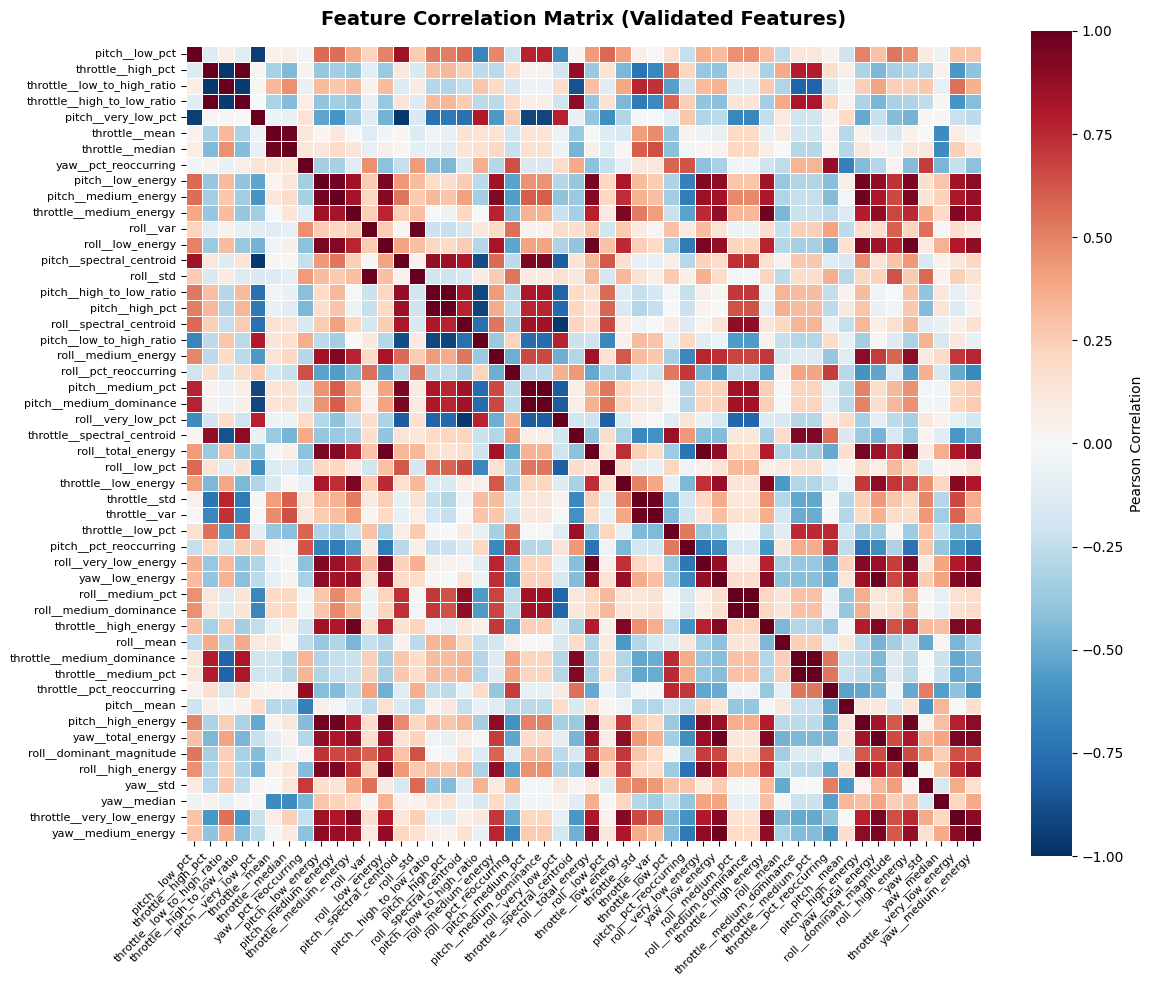


Final feature matrix: (46, 23)


In [12]:
# ============================================================================
# STEP 2: CORRELATION MATRIX (remove redundancy)
# ============================================================================

import seaborn as sns
import matplotlib.pyplot as plt

print(f"  Using top {len(top_features_mi)} features from Mutual Information directly")
print("\n" + "="*80)
print("CORRELATION ANALYSIS (remove redundant features)")
print("="*80)

# Compute correlation matrix
corr_matrix = np.corrcoef(X_filtered_mi.T)

# Create DataFrame for easier handling
corr_df = pd.DataFrame(
    corr_matrix,
    index=top_features_mi,
    columns=top_features_mi
)
# Find highly correlated pairs
high_corr_threshold = 0.90
high_corr_pairs = []

# ── inside the high_corr_pairs loop, replace the perm_df_cv lookups ────────
for i in range(len(top_features_mi)):
    for j in range(i+1, len(top_features_mi)):
        corr_val = abs(corr_matrix[i, j])
        if corr_val > high_corr_threshold:
            feat_i = top_features_mi[i]
            feat_j = top_features_mi[j]

            # Use MI score to decide which to keep (higher MI = more informative)
            mi_i = mi_df[mi_df['feature'] == feat_i]['mi_score'].values[0]
            mi_j = mi_df[mi_df['feature'] == feat_j]['mi_score'].values[0]

            high_corr_pairs.append({
                'feature_1': feat_i,
                'feature_2': feat_j,
                'correlation': corr_val,
                'keep':   feat_i if mi_i > mi_j else feat_j,
                'remove': feat_j if mi_i > mi_j else feat_i
            })

# Remove redundant features
if len(high_corr_pairs) > 0:
    print(f"\n⚠️  Found {len(high_corr_pairs)} highly correlated pairs (|r| > {high_corr_threshold}):")
    print(f"{'Feature 1':<35} {'Feature 2':<35} {'Corr':<8} {'Action'}")
    print("-"*90)
    
    features_to_remove = set()
    for pair in high_corr_pairs:
        print(f"{pair['feature_1']:<35} {pair['feature_2']:<35} "
              f"{pair['correlation']:.3f}  Remove {pair['remove'][:20]}...")
        features_to_remove.add(pair['remove'])
    
    # Remove redundant features
    final_features = [f for f in top_features_mi if f not in features_to_remove]
    print(f"\n✓ Removed {len(features_to_remove)} redundant features")
else:
    print("\n✓ No highly correlated features found - all are relatively independent")
    final_features = top_features_mi

print(f"\n✓ Final feature set: {len(final_features)} features")

# Visualize correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_df,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation'}
)
plt.title('Feature Correlation Matrix (Validated Features)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# ============================================================================
# Store final feature indices
# ============================================================================
final_indices = [feature_names.index(f) for f in final_features]
X_final = X[:, final_indices]

print(f"\nFinal feature matrix: {X_final.shape}")


### Step 3: Final Feature Box Plots

- The final set of features is displayed for visual analysis


STEP 6: COMPARATIVE BOX PLOTS FOR ALL FEATURES

Plotting 23 final validated features


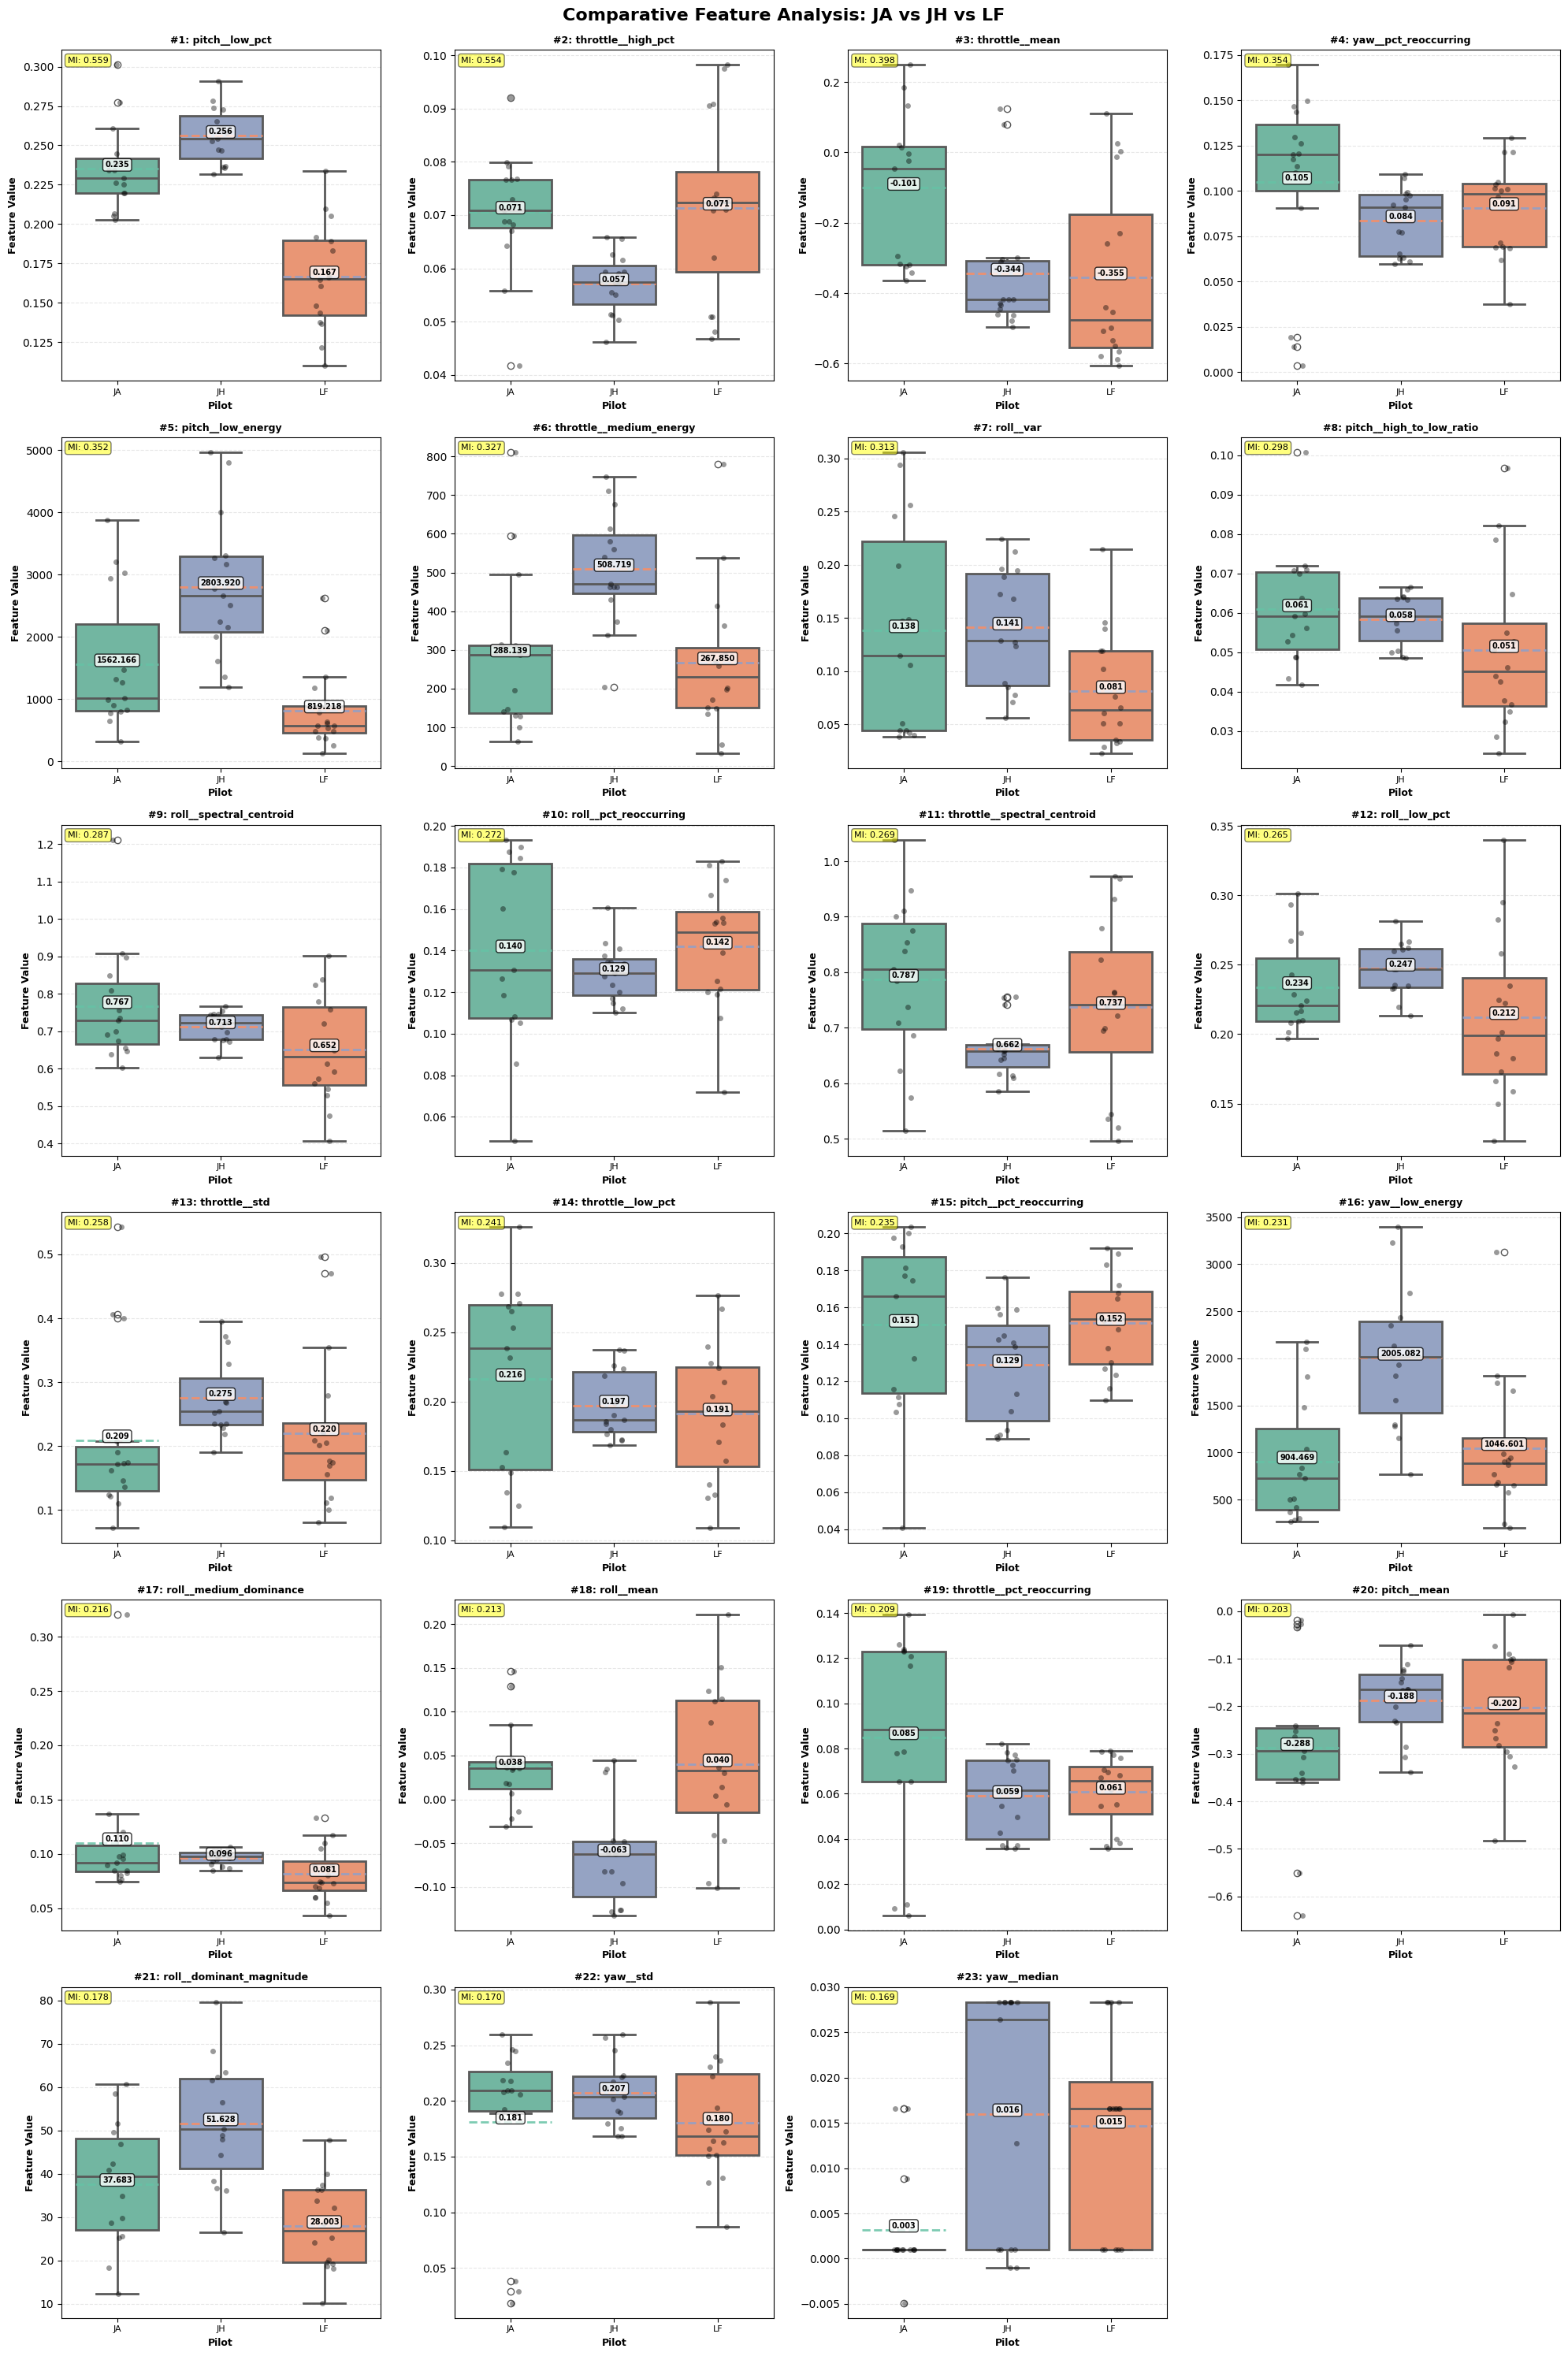


INTERPRETATION GUIDE

BOX PLOT ELEMENTS:
  • Box:        Middle 50% of data (IQR: 25th to 75th percentile)
  • Line:       Median (50th percentile)
  • Whiskers:   1.5 × IQR from box edges (typical range)
  • Points:     Individual flight measurements
  • Dashed:     Mean value for each pilot/class



In [13]:
# ============================================================================
# COMPARATIVE BOX PLOTS FOR ALL VALIDATED FEATURES (MULTICLASS)
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
from itertools import combinations

print("\n" + "="*80)
print("STEP 6: COMPARATIVE BOX PLOTS FOR ALL FEATURES")
print("="*80)

# Use final_features from Step 4, or fall back to top features
if 'final_features' in locals() and len(final_features) > 0:
    features_to_plot = final_features[:]  # Max 12 for clean layout
    print(f"\nPlotting {len(features_to_plot)} final validated features")
else:
    features_to_plot = mi_df.head(12)['feature'].tolist()
    print(f"\nPlotting top 12 features by Mutual Information")

# ── Get pilot/class info ──────────────────────────────────────────────────────
unique_classes = np.unique(y)
n_classes = len(unique_classes)
pilot_names = le.inverse_transform(unique_classes)

# Colour palette scaled to number of classes
palette = sns.color_palette('Set2', n_classes)

# ── Layout ────────────────────────────────────────────────────────────────────
n_features = len(features_to_plot)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

# ── Per-feature plots ─────────────────────────────────────────────────────────
for idx, feature in enumerate(features_to_plot):
    ax = axes[idx]

    feat_idx = feature_names.index(feature)
    feat_values = X[:, feat_idx]

    plot_data = pd.DataFrame({
        'value': feat_values,
        'pilot': le.inverse_transform(y)
    })

    # Box plot
    sns.boxplot(
        data=plot_data,
        x='pilot', y='value',
        hue='pilot',
        ax=ax,
        palette='Set2',
        linewidth=2,
        order=pilot_names,
        legend=False
    )

    # Individual points
    sns.stripplot(
        data=plot_data,
        x='pilot', y='value',
        ax=ax,
        color='black', alpha=0.4, size=5,
        jitter=True,
        order=pilot_names
    )

    # Per-class stats
    groups = [feat_values[y == c] for c in unique_classes]
    means  = [np.mean(g) for g in groups]

    # Mean dashed lines + annotation
    for i, (mean_val, pname) in enumerate(zip(means, pilot_names)):
        ax.hlines(mean_val, i - 0.4, i + 0.4,
                  colors=palette[i], linestyles='--', linewidth=2, alpha=0.85)
        ax.text(i, mean_val, f'{mean_val:.3f}',
                ha='center', va='bottom', fontsize=7, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Title
    short_name = feature if len(feature) <= 35 else feature[:32] + "..."
    ax.set_title(f"#{idx+1}: {short_name}", fontsize=9, fontweight='bold')

    ax.set_xlabel('Pilot', fontsize=9, fontweight='bold')
    ax.set_ylabel('Feature Value', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')

    # MI score annotation
    try:
        mi_score = mi_df[mi_df['feature'] == feature]['mi_score'].values[0]
        ax.text(0.02, 0.98, f'MI: {mi_score:.3f}',
                transform=ax.transAxes, va='top', ha='left',
                fontsize=8, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
    except Exception:
        pass


# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

pilot_label = ' vs '.join(pilot_names)
plt.suptitle(
    f'Comparative Feature Analysis: {pilot_label}',
    fontsize=16, fontweight='bold', y=0.995
)
plt.tight_layout()
plt.show()

# ── INTERPRETATION GUIDE ──────────────────────────────────────────────────────

print("\n" + "="*80)
print("INTERPRETATION GUIDE")
print("="*80)

print(f"""
BOX PLOT ELEMENTS:
  • Box:        Middle 50% of data (IQR: 25th to 75th percentile)
  • Line:       Median (50th percentile)
  • Whiskers:   1.5 × IQR from box edges (typical range)
  • Points:     Individual flight measurements
  • Dashed:     Mean value for each pilot/class
""")


## 4. MODEL PREP AND VALIDATION
---

###  4.a Model Architectures

- Both are *Multilayer Perceptron* models (MLP)
- There are two architectures to be selected
    - PilotMLP (single hidden layer)
    - PilotTripleMLP (three hidden layers)

In [14]:
import torch
import torch.nn as nn

# Simple MLP with one Hidden Layer
class PilotMLP(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=16, output_dim=1, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, x):
        return self.net(x)

# Simple MLP with three hidden layers
class PilotTripleMLP(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=16, output_dim=1, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, x):
        return self.net(x)

### 4.b Model Definition

In [15]:
from sklearn.preprocessing import LabelEncoder
# Print the list of funneled features
print(f"List of funneled features: {final_features}")

# ============================================================================
# Manual Feature Removal or Addition
# - top_feat is the final list of feature names 
# - To override the final set and remove any features, use the commented-out manual declaration
# ============================================================================

top_feat = final_features
# OVERRIDE
# top_feat = [*the above printed list minus any features you dont want*]
print(f"Number of features / model inputs: {len(final_features)}")

final_indices = [final_features.index(f) for f in top_feat] # checks for override
X = X_final[:, final_indices]

le = LabelEncoder()
y = le.fit_transform(pilot_labels)


# Model Parameters
INPUTS = len(top_feat)
N_CLASSES = len(PILOTS)
HIDDEN = 16
MODEL_CLASS = PilotTripleMLP

List of funneled features: ['pitch__low_pct', 'throttle__high_pct', 'throttle__mean', 'yaw__pct_reoccurring', 'pitch__low_energy', 'throttle__medium_energy', 'roll__var', 'pitch__high_to_low_ratio', 'roll__spectral_centroid', 'roll__pct_reoccurring', 'throttle__spectral_centroid', 'roll__low_pct', 'throttle__std', 'throttle__low_pct', 'pitch__pct_reoccurring', 'yaw__low_energy', 'roll__medium_dominance', 'roll__mean', 'throttle__pct_reoccurring', 'pitch__mean', 'roll__dominant_magnitude', 'yaw__std', 'yaw__median']
Number of features / model inputs: 23


### 4.c Leave One Out Validation

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut

loo    = LeaveOneOut()
scores = []

# ======================================
# Training Loop for each individual fold
# ======================================
def train_fold(X_train, y_train, X_val, y_val, epochs=500, lr=1e-3, fold=None, plot=False):
    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.long)        # ← long, no unsqueeze
    X_v  = torch.tensor(X_val,   dtype=torch.float32)
    y_v  = torch.tensor(y_val,   dtype=torch.long)        # ← long, no unsqueeze

    model = MODEL_CLASS(input_dim=INPUTS, hidden_dim=HIDDEN, output_dim=N_CLASSES)  # ← N_CLASSES
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-3)
    criterion = nn.CrossEntropyLoss()                      

    train_losses = []
    val_losses   = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        train_loss = criterion(model(X_tr), y_tr)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_v), y_v)

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

    # Final accuracy — multiclass argmax
    model.eval()
    with torch.no_grad():
        preds = torch.argmax(model(X_v), dim=1)
        acc   = (preds == y_v).float().mean().item()

    # Display Training Loss Graphs
    if plot == True:
        plt.figure(figsize=(8, 4))
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses,   label='Val Loss')
        plt.xlabel('Epoch'); plt.ylabel('CrossEntropy Loss')
        plt.title(f'Loss Curve (Fold {fold})')
        plt.legend(); plt.tight_layout(); plt.show()
        plt.close()
    
    return acc, model


# ==================================
# Actually Perform LOO Validation
# ==================================
for fold, (train_idx, val_idx) in enumerate(loo.split(X, y), start=1):
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X[train_idx])
    X_val   = scaler.transform(X[val_idx])

    # Use above Function
    acc, model = train_fold(X_train, y[train_idx], X_val, y[val_idx], epochs=500, fold=fold,lr=1e-3)

    scores.append(acc)
    flight_name = flight_names[val_idx[0]]
    true_label  = le.inverse_transform(y[val_idx])[0]
    with torch.no_grad():
        out = model(torch.tensor(X_val, dtype=torch.float32))
        pred_idx = torch.argmax(out, dim=1).item()
        pred_label = le.inverse_transform([pred_idx])[0]
    print(f"  Fold {fold} Accuracy: {acc:.3f} | Flight: {flight_name} -> {true_label} | Predicted: {pred_label} | {'✓' if acc == 1.0 else '✗'}")

print(f"\nCV Accuracy: {np.mean(scores):.3f}  ({sum(s==1.0 for s in scores)}/{len(scores)} correct)")

for pilot in le.classes_:
    pilot_mask = [le.inverse_transform([y[i]])[0] == pilot for i in range(len(y))]
    pilot_scores = [s for s, m in zip(scores, pilot_mask) if m]
    correct = sum(s == 1.0 for s in pilot_scores)
    print(f"{pilot} accuracy: {correct}/{len(pilot_scores)}")

  Fold 1 Accuracy: 1.000 | Flight: 095G_JA -> JA | Predicted: JA | ✓
  Fold 2 Accuracy: 1.000 | Flight: 097G_JA -> JA | Predicted: JA | ✓
  Fold 3 Accuracy: 1.000 | Flight: 101G_JA -> JA | Predicted: JA | ✓
  Fold 4 Accuracy: 1.000 | Flight: 119G_LF -> LF | Predicted: LF | ✓
  Fold 5 Accuracy: 1.000 | Flight: 120G_LF -> LF | Predicted: LF | ✓
  Fold 6 Accuracy: 1.000 | Flight: 121G_LF -> LF | Predicted: LF | ✓
  Fold 7 Accuracy: 0.000 | Flight: 128G_LF -> LF | Predicted: JH | ✗
  Fold 8 Accuracy: 1.000 | Flight: 129G_LF -> LF | Predicted: LF | ✓
  Fold 9 Accuracy: 1.000 | Flight: 141G_LF -> LF | Predicted: LF | ✓
  Fold 10 Accuracy: 1.000 | Flight: 142G_LF -> LF | Predicted: LF | ✓
  Fold 11 Accuracy: 1.000 | Flight: 147B_JA -> JA | Predicted: JA | ✓
  Fold 12 Accuracy: 1.000 | Flight: 152B_JH -> JH | Predicted: JH | ✓
  Fold 13 Accuracy: 1.000 | Flight: 154B_JA -> JA | Predicted: JA | ✓
  Fold 14 Accuracy: 1.000 | Flight: 155G_LF -> LF | Predicted: LF | ✓
  Fold 15 Accuracy: 1.000 | F

## 5. FINAL TRAIN AND SAVE
---

TRAINING FINAL MODEL ON COMPLETE DATASET

Training for 250 epochs...
Epoch      Loss         Accuracy    
----------------------------------------
1          1.0884       0.348       
100        0.6935       0.870       
200        0.2464       0.935       

Training complete!
  Final loss:     0.1661
  Final accuracy: 0.957

Generating training curves...


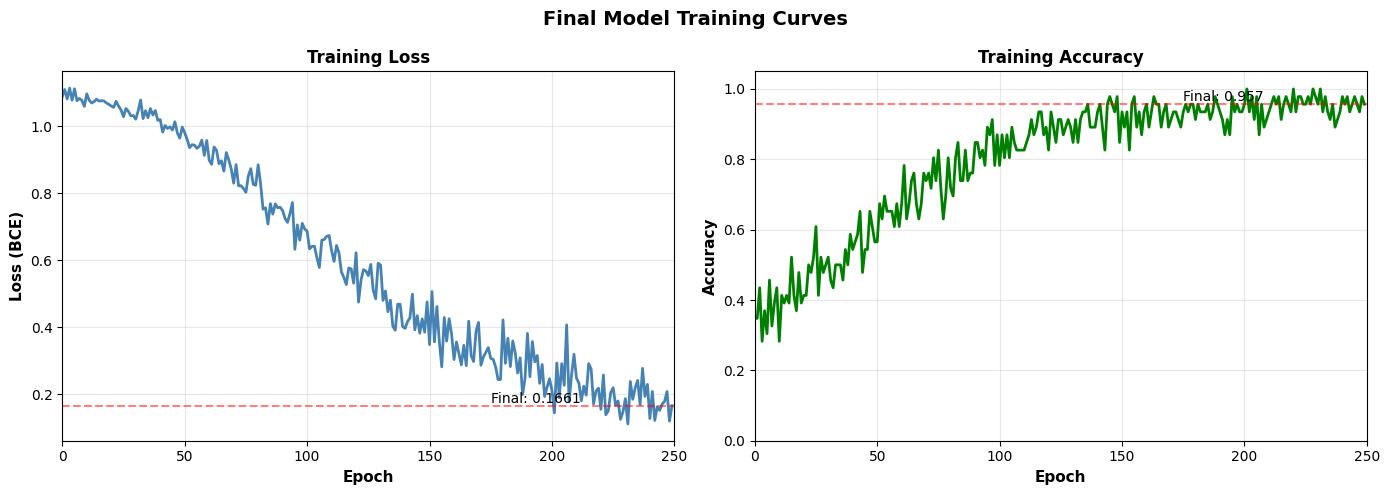


FINAL MODEL EVALUATION ON TRAINING SET

Overall training accuracy: 1.000  (46/46)

Per-pilot performance:
  JA: 1.000  (15/15)
  JH: 1.000  (15/15)
  LF: 1.000  (16/16)

✓ Perfect training accuracy - all samples correctly classified

SAVING MODEL PACKAGE
✓ Model package saved to: pilot_model.pkl

Package contents:
  • Features:        23 selected features
  • Scaler:          StandardScaler (fitted on training data)
  • Label Encoder:   JA:0 → JH:1 → LF:2
  • Model:           PilotTinyMLP
  • Training Acc:    1.000

To use this model:

1. Load the package:
   with open('pilot_model.pkl', 'rb') as f:
       pkg = pickle.load(f)



In [17]:
# =========================================
# FINAL MODEL TRAINING - Full Training Set
# =========================================

import torch
import torch.nn as nn
import torch.optim as optim
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

print("=" * 80)
print("TRAINING FINAL MODEL ON COMPLETE DATASET")
print("=" * 80)

# ── 0. SET HYPERPARAMETERS ───────────────────────────────────────────────────

n_epochs = 250 # Training Epochs
print_every = 100 # How often to print a status update

model_save_name = "pilot_model.pkl" # Model savename (must in in .pkl)

# Final chance to tweak the model before final training
HIDDEN = 16
DROP = .3

# ── 1. FEATURE SCALING ───────────────────────────────────────────────────────

scaler_final = StandardScaler()
X_all_scaled = scaler_final.fit_transform(X)

# ── 2. MODEL INITIALIZATION ──────────────────────────────────────────────────

model_final = MODEL_CLASS(input_dim=INPUTS, hidden_dim= HIDDEN, output_dim=N_CLASSES, dropout=DROP)

# ── 3. TRAINING SETUP ────────────────────────────────────────────────────────

# Optimizer
learning_rate = 1e-3
weight_decay = 1e-3
optimizer = torch.optim.Adam(
    model_final.parameters(), 
    lr=learning_rate, 
    weight_decay=weight_decay
)

# Loss function
criterion = nn.CrossEntropyLoss()

# Convert to tensors
X_tensor = torch.tensor(X_all_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

# ── 4. TRAINING LOOP ─────────────────────────────────────────────────────────

print(f"\nTraining for {n_epochs} epochs...")
print(f"{'Epoch':<10} {'Loss':<12} {'Accuracy':<12}")
print("-" * 40)

losses = []
accuracies = []

for epoch in range(n_epochs):
    # Forward pass
    model_final.train()
    optimizer.zero_grad()
    
    outputs = model_final(X_tensor)
    loss = criterion(outputs, y_tensor)
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    # Track metrics
    losses.append(loss.item())
    
    # Calculate accuracy
    with torch.no_grad():
        predictions = torch.argmax(outputs, dim=1)
        accuracy = (predictions == y_tensor).float().mean().item()
        accuracies.append(accuracy)
    
    # Print progress
    if (epoch + 1) % print_every == 0 or epoch == 0:
        print(f"{epoch+1:<10} {loss.item():<12.4f} {accuracy:<12.3f}")

# Final metrics
print("\n" + "=" * 40)
print(f"Training complete!")
print(f"  Final loss:     {losses[-1]:.4f}")
print(f"  Final accuracy: {accuracies[-1]:.3f}")
print("=" * 40)

# ── 6. TRAINING VISUALIZATION ────────────────────────────────────────────────

print(f"\nGenerating training curves...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(losses, linewidth=2, color='steelblue')
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loss (BCE)', fontsize=11, fontweight='bold')
ax1.set_title('Training Loss', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, n_epochs])

# Add final loss annotation
ax1.axhline(losses[-1], color='red', linestyle='--', alpha=0.5)
ax1.text(n_epochs * 0.7, losses[-1], f'Final: {losses[-1]:.4f}', 
         fontsize=10, va='bottom')

# Accuracy curve
ax2.plot(accuracies, linewidth=2, color='green')
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax2.set_title('Training Accuracy', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, n_epochs])
ax2.set_ylim([0, 1.05])

# Add final accuracy annotation
ax2.axhline(accuracies[-1], color='red', linestyle='--', alpha=0.5)
ax2.text(n_epochs * 0.7, accuracies[-1], f'Final: {accuracies[-1]:.3f}', 
         fontsize=10, va='bottom')

plt.suptitle('Final Model Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 7. FINAL MODEL EVALUATION ────────────────────────────────────────────────

print(f"\n" + "=" * 80)
print("FINAL MODEL EVALUATION ON TRAINING SET")
print("=" * 80)

model_final.eval()
with torch.no_grad():
    final_outputs = model_final(X_tensor)
    final_predictions = torch.argmax(final_outputs, dim=1).numpy()

# Overall accuracy
train_accuracy = (final_predictions == y).mean()
print(f"\nOverall training accuracy: {train_accuracy:.3f}  ({(final_predictions == y).sum()}/{len(y)})")

# Per-pilot accuracy
print(f"\nPer-pilot performance:")
for pilot in le.classes_:
    pilot_idx = le.transform([pilot])[0]
    mask = y == pilot_idx
    if mask.sum() > 0:
        pilot_acc = (final_predictions[mask] == y[mask]).mean()
        n_correct = (final_predictions[mask] == y[mask]).sum()
        n_total = mask.sum()
        print(f"  {pilot}: {pilot_acc:.3f}  ({n_correct}/{n_total})")

# Show misclassifications
misclassified = final_predictions != y
if misclassified.sum() > 0:
    print(f"\n⚠️  Misclassified training samples: {misclassified.sum()}")
    print(f"{'Flight':<30} {'True':<10} {'Predicted':<10} {'Confidence'}")
    print("-" * 65)
    for i, (name, is_wrong) in enumerate(zip(flight_names, misclassified)):
        if is_wrong:
            true_label = le.inverse_transform([y[i]])[0]
            pred_label = le.inverse_transform([final_predictions[i]])[0]
            
            # Get softmax probabilities, then take the predicted class confidence
            probs = torch.softmax(final_outputs[i], dim=0)
            confidence = probs[final_predictions[i]].item()  # scalar now
            
            print(f"{name:<30} {true_label:<10} {pred_label:<10} {confidence:.3f}")
else:
    print(f"\n✓ Perfect training accuracy - all samples correctly classified")

# ── 8. SAVE MODEL PACKAGE ────────────────────────────────────────────────────

print(f"\n" + "=" * 80)
print("SAVING MODEL PACKAGE")
print("=" * 80)

model_package = {
    # Feature configuration
    'final_features': final_features,
    'feature_names': feature_names,
    'top_feat': top_feat,    
    'n_features': len(final_features),
    
    # Data preprocessing
    'scaler': scaler_final,
    'label_encoder': le,
    
    # Model
    'trained_model': model_final,
    'model_architecture': 'PilotTinyMLP',
    'input_dim': INPUTS,
    
    # Training metadata
    'training_samples': len(y),
    'training_accuracy': train_accuracy,
    'n_epochs': n_epochs,
    'final_loss': losses[-1],
    
    # Pilots
    'pilots': le.classes_.tolist(),
    'pilot_encoding': {pilot: le.transform([pilot])[0] for pilot in le.classes_}
}

save_path = model_save_name
with open(save_path, 'wb') as f:
    pickle.dump(model_package, f)

print(f"✓ Model package saved to: {save_path}")
print(f"\nPackage contents:")
print(f"  • Features:        {len(final_features)} selected features")
print(f"  • Scaler:          StandardScaler (fitted on training data)")
print(f"  • Label Encoder:   {' → '.join([f'{p}:{i}' for p, i in model_package['pilot_encoding'].items()])}")
print(f"  • Model:           {model_package['model_architecture']}")
print(f"  • Training Acc:    {train_accuracy:.3f}")

print(f"\nTo use this model:")
print(f"""
1. Load the package:
   with open('{save_path}', 'rb') as f:
       pkg = pickle.load(f)
""")

## 6. TESTING
---

### 6.a Data Prep

In [18]:
# Skip if True
data_cleaned = 0

test_flight_names = []

if data_cleaned == False:
        fn.folder_cleaner(TEST_DATA_DIR, TEST_CSV_DIR, skip= True, downsample= True)
        for file in os.listdir(TEST_DATA_DIR):
                filename = os.path.basename(file)
                if filename.lower().endswith(".xlsx"):
                        test_flight_names.append(filename[4:14])

print(f"test_flight_names:{test_flight_names}")

test_flights, _ = pt.unpack_csv_dir(TEST_CSV_DIR)
test_labels = pt.get_pilot_labels(TEST_CSV_DIR, PILOTS)

test_names = test_flight_names

clip175B_JA_FD_L.xlsx skipped due to existing duplicate.
clip177B_JA_FD_L.xlsx skipped due to existing duplicate.
clip177G_LF_CG_L.xlsx skipped due to existing duplicate.
clip179B_JA_FD_L.xlsx skipped due to existing duplicate.
clip181B_JA_FD_L.xlsx skipped due to existing duplicate.
clip183B_JA_FD_L.xlsx skipped due to existing duplicate.
clip221G_LF_CG_L.xlsx skipped due to existing duplicate.
clip240G_LF_CG_L.xlsx skipped due to existing duplicate.
clip242G_LF_CG_L.xlsx skipped due to existing duplicate.
clip244G_LF_CG_L.xlsx skipped due to existing duplicate.
clip259G_JH_CG_L.xlsx skipped due to existing duplicate.
clip261G_JH_CG_L.xlsx skipped due to existing duplicate.
clip276G_JH_CG_L.xlsx skipped due to existing duplicate.
clip277G_JH_CG_L.xlsx skipped due to existing duplicate.
clip278G_JH_CG_L.xlsx skipped due to existing duplicate.
clip279G_JH_CG_L.xlsx skipped due to existing duplicate.
clip280G_JH_CG_L.xlsx skipped due to existing duplicate.
clip281G_JH_CG_L.xlsx skipped d

### 6.b Load Saved Model and Test

In [29]:
import pickle

print("─────────── EVALUATE MODEL ───────────")

# ── 1. SELECT AND LOAD SAVED MODEL ───────────────────────────────────────────────────

# MODEL = "ThreeLayer_97_2_FINAL"
MODEL = "pilot_model"

with open(f"{MODEL}.pkl", 'rb') as f:
    pkg = pickle.load(f)

top_feat = pkg['top_feat']  # ← load from package

# ── 2. GET DATA AND EXTRACT FEATURES ───────────────────────────────────────────────────

# Pair and filter
paired = [(f, n, l) for f, n, l in zip(test_flights, test_names, test_labels) if l is not None]
test_flights, test_names, test_labels = zip(*paired)

normalized_test_flights = normalize_rcin(test_flights)
new_flight_features_all = [extract_my_features(f) for f in normalized_test_flights]
X_new_all = np.array(new_flight_features_all)

final_indices = [pkg['feature_names'].index(f) for f in top_feat]
X_new = X_new_all[:, final_indices]              

# ── 3. SCALE DATA ───────────────────────────────────────────────────

X_new_scaled = pkg['scaler'].transform(X_new)

X_tensor = torch.tensor(X_new_scaled, dtype=torch.float32)

# ── 4. LOAD AND EVALUATE MODEL ───────────────────────────────────────────────────

model = pkg['trained_model']
# print(type(model))
print(f"\nLOADED MODEL\n\n{model}")
model.eval()

with torch.no_grad():
    outputs = model(X_tensor)
    probs = torch.softmax(outputs, dim=1)
    y_pred = torch.argmax(probs, dim=1).numpy()

# ── 5. PRINT OUT RESULTS ───────────────────────────────────────────────────

pilot_names = pkg['label_encoder'].inverse_transform(y_pred)

print(f"\n{'Flight':<12} {'Predicted':<12} {'Confidence'}")
print("-" * 40)
for name, pred_label, prob_row in zip(test_names, pilot_names, probs.numpy()):
    print(f"{name:<12} {pred_label:<12} {prob_row.max():.3f}")

if test_labels is not None:
    y_true = pkg['label_encoder'].transform(test_labels)
    accuracy = (y_pred == y_true).mean()
    print(f"\n{'='*40}")
    print(f"Test Accuracy: {accuracy:.3f}  ({(y_pred == y_true).sum()}/{len(y_true)} correct)")
    for pilot in pkg['label_encoder'].classes_:
        pilot_idx = pkg['label_encoder'].transform([pilot])[0]
        mask = y_true == pilot_idx
        if mask.sum() > 0:
            pilot_acc = (y_pred[mask] == y_true[mask]).mean()
            print(f"  {pilot}: {pilot_acc:.3f}  ({(y_pred[mask] == y_true[mask]).sum()}/{mask.sum()})")

─────────── EVALUATE MODEL ───────────

LOADED MODEL

PilotTripleMLP(
  (net): Sequential(
    (0): Linear(in_features=23, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=16, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=16, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=16, out_features=3, bias=True)
  )
)

Flight       Predicted    Confidence
----------------------------------------
175B_JA_FD   JA           0.999
177B_JA_FD   JA           1.000
177G_LF_CG   LF           0.994
179B_JA_FD   JA           0.999
181B_JA_FD   JA           0.999
183B_JA_FD   JA           1.000
221G_LF_CG   LF           0.991
240G_LF_CG   LF           0.994
242G_LF_CG   LF           0.999
244G_LF_CG   LF           0.993
259G_JH_CG   JH           0.915
261G_JH_CG   LF           0.965
276G_JH_CG   JH           0.931
277G

## 7. FINAL OUTPUT MATRICES
---

### 7.a Confusion Matrix

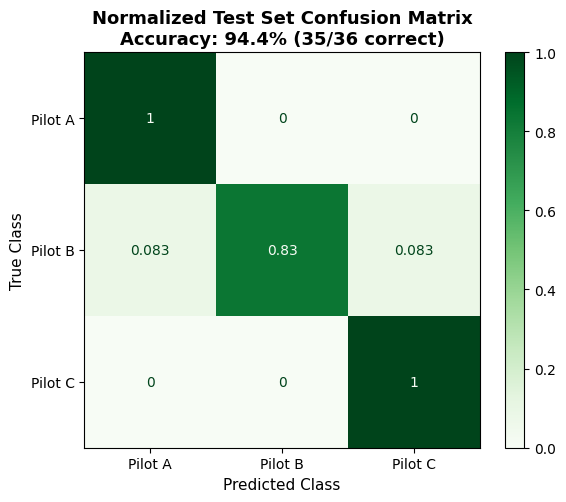

In [22]:
# ── CONFUSION MATRIX ─────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Optional: overwrite display names here, or leave as None to use pilot labels
display_names = ["Pilot A", "Pilot B", "Pilot C"]
# display_names = None

labels = display_names if display_names else pkg['label_encoder'].classes_.tolist()

cm = confusion_matrix(y_true, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=True, cmap='Greens')
ax.set_title(f"Normalized Test Set Confusion Matrix\nAccuracy: {accuracy*100:.1f}% (35/36 correct)", fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Class', fontsize=11)
ax.set_ylabel('True Class', fontsize=11)
plt.tight_layout()
plt.show()

### 7.b Confidence Matrix

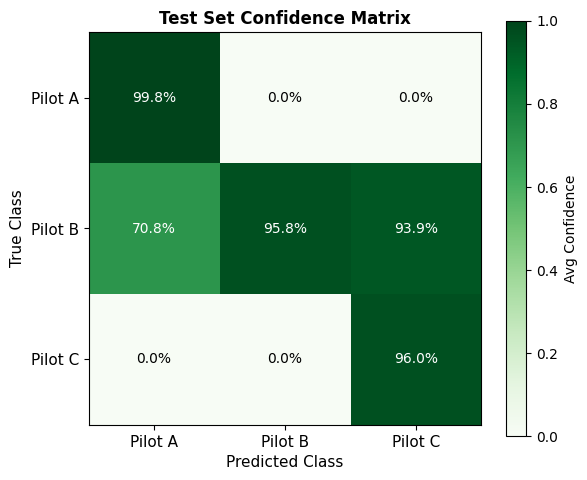

In [23]:
# ── CONFIDENCE MATRIX ────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# Optional: overwrite display names here, or leave as None to use pilot labels
display_names = ["Pilot A", "Pilot B", "Pilot C"]

labels = display_names if display_names else pkg['label_encoder'].classes_.tolist()
n_classes = len(labels)

# Build matrix: rows = true class, cols = predicted class, values = avg confidence of prediction
conf_matrix = np.zeros((n_classes, n_classes))
count_matrix = np.zeros((n_classes, n_classes))

for true, pred_idx, prob_row in zip(y_true, y_pred, probs.numpy()):
    conf_matrix[true][pred_idx] += prob_row[pred_idx]  # only the predicted class confidence
    count_matrix[true][pred_idx] += 1

# Average confidence per cell
with np.errstate(invalid='ignore'):
    avg_conf_matrix = np.where(count_matrix > 0, conf_matrix / count_matrix, 0)

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(avg_conf_matrix, cmap='Greens', vmin=0, vmax=1)

# Annotate cells
for i in range(n_classes):
    for j in range(n_classes):
        val = avg_conf_matrix[i][j]
        color = 'white' if val > avg_conf_matrix.max() / 2 else 'black'
        ax.text(j, i, f"{val*100:.1f}%", ha='center', va='center',
                fontsize=10, color=color)

ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Predicted Class', fontsize=11)
ax.set_ylabel('True Class', fontsize=11)
ax.set_title('Test Set Confidence Matrix', fontsize=12, fontweight='bold')

plt.colorbar(im, ax=ax, label='Avg Confidence')
plt.tight_layout()
plt.show()